# Drought stress detection in wheat using machine learning — reproduction of the classifier result

**Paper:** Gupta, A., Kaur, H. & Kaur, T. (2023). *Drought stress detection technique for wheat crop using machine learning.* PeerJ Computer Science 9:e1268, DOI [10.7717/peerj-cs.1268](https://doi.org/10.7717/peerj-cs.1268) (PMCID [PMC10280683](https://www.ncbi.nlm.nih.gov/pmc/PMC10280683/), CC BY 4.0).

**Scope — PARTIAL DEMONSTRATION.** This notebook reproduces the paper's headline result: the water-stress (drought vs. control) classifiers, in particular **Random Forest (test AUC 0.9116)**, evaluated with **10-fold cross-validation** on the **authors' own deposited feature matrix** (23 correlation-based GLCM + 9 colour-band proportion features for wheat cv. Raj 3765). It does **not** re-derive features from raw images, and does not reproduce the Cfit k-means segmentation.

**実行内容（日本語）:** 論文の主要結果（RF test AUC 0.9116）を、著者自身が公開した特徴量行列と Table 3 のハイパーパラメータ、10分割交差検証で再現します。画像からの特徴量再計算や Cfit k-means セグメンテーションは対象外です。

**Execution status:** validated end-to-end on a fresh Colab CPU runtime (see validation record at the bottom).

**Data (CC BY 4.0):** Mendeley deposit [10.17632/2mpd7d3vry](https://data.mendeley.com/datasets/2mpd7d3vry/4) — `XyWheatCW.npy` (features), `YWheatCW.npy` (labels), `YWheatCWModels.npy` (model names). Secondary demo image from [10.17632/jnjd835ncg](https://data.mendeley.com/datasets/jnjd835ncg/2).

## 1. Runtime selection / ランタイム選択

**No GPU is needed.** The method is classical scikit-learn on a small matrix (tens of thousands of rows × 32 features); total runtime is a few minutes on CPU. Select **Runtime → Change runtime type → CPU** (standard RAM is fine), then *Runtime → Run all*.

**GPUは不要です。** 古典的機械学習（scikit-learn）のため、CPUランタイムで数分で完了します。「ランタイム → すべてのセルを実行」で実行してください。

Expected: ~15 MB of downloads, < 5 min wall time (measured values appear in the outputs).

In [ ]:
import sys, numpy, pandas, sklearn, matplotlib
print("python:", sys.version)
print("numpy:", numpy.__version__, "| pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__, "| matplotlib:", matplotlib.__version__)

python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy: 2.1.3 | pandas: 2.2.3
scikit-learn: 1.6.1 | matplotlib: 3.10.0


## 2. Download the authors' deposited feature matrix / 特徴量データの取得

Download the three `.npy` files from the Mendeley deposit `10.17632/2mpd7d3vry` (public files endpoint; redirects to the deposit's S3 storage) and **verify SHA-256 and byte size** against the deposit metadata recorded on 2026-10-02 from the public Mendeley API.

**入力:** Mendeley公開デポジットから `.npy` を3つ取得し、SHA-256とサイズを検証します。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

DATA_DIR = Path("/content/wheat_stress_data"); DATA_DIR.mkdir(exist_ok=True)

# data.mendeley.com fronts its S3 storage with Cloudflare and rejects the default
# python-urllib User-Agent with 403; a normal browser-style UA is required.
UA = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36"}

def fetch_mendeley(url: str, dest: Path) -> None:
    req = urllib.request.Request(url, headers=UA)
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:  # follows the S3 redirect
        f.write(r.read())

# filename -> (download_url, expected_sha256, expected_size_bytes)
FILES = {
    "XyWheatCW.npy": (
        "https://data.mendeley.com/public-files/datasets/2mpd7d3vry/files/e44f1023-0e43-409d-b749-c0be304df1be/file_downloaded",
        "6bb543f3119ac84809f47108706a733e1d8d950294055b2948f2fbca66dda688", 4_436_096),
    "YWheatCW.npy": (
        "https://data.mendeley.com/public-files/datasets/2mpd7d3vry/files/2382dee0-7047-4b48-a774-ae27e475d88a/file_downloaded",
        "f4f50c6bf75c55fdcf2653418aec58f1647f3cc84c90e4011c865f01d89427e9", 138_752),
    "YWheatCWModels.npy": (
        "https://data.mendeley.com/public-files/datasets/2mpd7d3vry/files/fd4bfa8b-b7e0-4f80-a785-c087162236bc/file_downloaded",
        "4139d80fd023196b1e13a8a5133b70f65d59afac4c0ef2b328217e40342b3691", 1_208),
}

for fname, (url, sha, size) in FILES.items():
    dest = DATA_DIR / fname
    if not dest.exists():
        print("downloading", fname, "...")
        fetch_mendeley(url, dest)
    blob = dest.read_bytes()
    assert len(blob) == size, f"{fname}: expected {size} bytes, got {len(blob)}"
    digest = hashlib.sha256(blob).hexdigest()
    assert digest == sha, f"{fname}: sha256 mismatch: {digest}"
    print(f"OK {fname}: {len(blob):,} bytes, sha256 verified")

downloading XyWheatCW.npy ...


OK XyWheatCW.npy: 4,436,096 bytes, sha256 verified
downloading YWheatCW.npy ...


OK YWheatCW.npy: 138,752 bytes, sha256 verified
downloading YWheatCWModels.npy ...


OK YWheatCWModels.npy: 1,208 bytes, sha256 verified


## 3. Inspect the data / データの中身の確認

The paper states the feature set is **23 correlation-based GLCM metrics + 9 colour-band proportions** (blue, green, red, lightness, green-magenta, blue-yellow, hue, saturation, value) = **32 columns**, with drought/control labels and the list of prototyped model names. The deposit's column semantics are not stored in the `.npy` files, so columns are treated as unnamed.

**確認:** 行列の形状・型・クラス比率とモデル名一覧を表示します。

In [ ]:
X = numpy.load(DATA_DIR / "XyWheatCW.npy")
y = numpy.load(DATA_DIR / "YWheatCW.npy")
model_names = numpy.load(DATA_DIR / "YWheatCWModels.npy", allow_pickle=True)

print("X:", X.shape, X.dtype, "| y:", y.shape, y.dtype)
print("unique labels:", numpy.unique(y, return_counts=True))
if model_names.dtype == object or model_names.size < 30:
    print("model names:", model_names)
assert X.shape[1] == 32, f"expected 32 features (23 CGLCM + 9 colour bands), got {X.shape[1]}"
classes, counts = numpy.unique(y, return_counts=True)
print("observed label values:", dict(zip(classes.tolist(), counts.tolist())))
assert classes.size == 2, f"expected two classes (control/drought), got {classes}"
assert counts.min() > 0.45 * X.shape[0], "unexpectedly unbalanced classes (paper: 1440+1440 before augmentation)"
# binary target: the larger sorted label is the positive class (drought);
# the authors' formatting notebook used group 1 = control, group 2 = drought
y01 = (y == classes[1]).astype(int)
print(f"positive class (drought) = label {classes[1]!r}: {counts[1]} rows; control = {classes[0]!r}: {counts[0]} rows")

X: (17328, 32) float64 | y: (17328,) int64
unique labels: (array([0, 1]), array([8678, 8650]))
observed label values: {0: 8678, 1: 8650}
positive class (drought) = label np.int64(1): 8650 rows; control = np.int64(0): 8678 rows


## 4. The nine classifiers with the paper's Table 3 hyperparameters / Table 3 のハイパーパラメータで9分類器を定義

Hyperparameters are transcribed from **Table 3** of the paper ("Hyper parameters found by grid search method"). Where Table 3 names are descriptive rather than scikit-learn arguments, the mapping below is documented:

- **NB**: Table 3 lists descriptive statistics (2 classes, min-max normalization already applied to features, class probability 0.5, smoothing 1) — instantiated as `GaussianNB()` defaults; min-max normalization is *not* re-applied because the deposited features are the model-ready matrix used by the authors.
- **LDA**: `solver="lsqr"`, `shrinkage="auto"`; Table 3's `tol=1` maps to no scikit-learn argument for the `lsqr` solver and is recorded but not applied.
- **LR**: `penalty="l2", C=0.98, solver="lbfgs", class_weight="balanced", multi_class="ovr", max_iter=100`; Table 3's `tol = 1` is recorded but not applied — scikit-learn's default `tol=1e-4` is used because applying `tol=1.0` verbatim stops optimization almost immediately and yields a degenerate classifier, contradicting the paper's reported LR AUC.
- **SVM**: `kernel="poly", C=4.5, gamma=0.01`; `probability=True` enables the AUC estimates (Platt scaling, an internal-fit detail the paper does not specify).
- **GBC**: `loss="log_loss", learning_rate=0.5, max_depth=3, n_estimators=50, min_samples_split=2`; Table 3's `criterion="mse"` is the legacy name of today's `"squared_error"`, and `max_features="auto"` was removed in scikit-learn 1.3 (it historically resolved to `"sqrt"`) → `"sqrt"`.
- **KNN**: `n_neighbors=5, leaf_size=20, weights="uniform", metric="minkowski", algorithm="auto"`.
- **RF / ETC / DT**: tree parameters exactly as tabulated; Table 3's `max_features = (no. of samples)` is interpreted as *all features* (`max_features=None` — the only reading that leaves every feature available to each split), `class_weight="balanced"`. Note: the ensemble classes (`RandomForestClassifier`, `ExtraTreesClassifier`) do not expose a `splitter` argument — growing best splitters is their only behavior — so `splitter="best"` is set explicitly only on the single `DecisionTreeClassifier`.

**Table 3 のハイパーパラメータを忠実に sklearn 引数へ写像します。** 論文の表記が現行 scikit-learn に存在しない場合（`criterion="mse"`、`max_features="auto"` など）は後継値に置き換え、注記しています。

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

models = {
    "NB":  GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
    "LR":  LogisticRegression(penalty="l2", C=0.98, solver="lbfgs", class_weight="balanced",
                              multi_class="ovr", max_iter=100),
    "SVM": SVC(kernel="poly", C=4.5, gamma=0.01, probability=True),
    "GBC": GradientBoostingClassifier(loss="log_loss", learning_rate=0.5, max_depth=3,
                                      n_estimators=50, criterion="squared_error",
                                      min_samples_split=2, max_features="sqrt"),
    "KNN": KNeighborsClassifier(n_neighbors=5, leaf_size=20, weights="uniform",
                                metric="minkowski", algorithm="auto"),
    "RF":  RandomForestClassifier(criterion="gini", max_depth=7,
                                  min_samples_split=10, min_samples_leaf=2,
                                  min_weight_fraction_leaf=0.0, max_features=None,
                                  class_weight="balanced", random_state=0),
    "ETC": ExtraTreesClassifier(criterion="gini", max_depth=5,
                                min_samples_split=10, min_samples_leaf=1,
                                min_weight_fraction_leaf=0.0, max_features=None,
                                class_weight="balanced", random_state=0),
    "DT":  DecisionTreeClassifier(criterion="gini", splitter="best", max_depth=3,
                                  min_samples_split=10, min_samples_leaf=1,
                                  min_weight_fraction_leaf=0.0, max_features=None,
                                  class_weight="balanced", random_state=0),
}
for name, m in models.items():
    print(f"{name}: {m.__class__.__name__}")

NB: GaussianNB
LDA: LinearDiscriminantAnalysis
LR: LogisticRegression
SVM: SVC
GBC: GradientBoostingClassifier
KNN: KNeighborsClassifier
RF: RandomForestClassifier
ETC: ExtraTreesClassifier
DT: DecisionTreeClassifier


## 5. 10-fold cross-validation, as in the paper / 論文と同じ10分割交差検証

The paper: "The results are validated using 10-fold cross-validation for all the algorithms" — each of 10 near-equal folds is used once as the validation set with the other 9 for fitting. For every classifier we record the **mean AUC over the 10 held-out (test) folds** and the **mean AUC over the 9 fitting folds**, comparable to Table 2's "AUC test" and "AUC train". A fixed `random_state=0` stratified split is used because the paper does not publish its fold seed; expect values near, not identical to, Table 2.

**論文の手順に従い、各分割を1回ずつ検証セットとしてAUCを測定します。** 分割シードは未公開のため `random_state=0` を使用し、結果は Table 2 と「近い値」になります。

In [ ]:
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
rows = []
for name, model in models.items():
    t0 = time.time()
    test_aucs, train_aucs = [], []
    for fit_idx, test_idx in skf.split(X, y01):
        model.fit(X[fit_idx], y01[fit_idx])
        p_test = model.predict_proba(X[test_idx])[:, 1]
        p_train = model.predict_proba(X[fit_idx])[:, 1]
        test_aucs.append(roc_auc_score(y01[test_idx], p_test))
        train_aucs.append(roc_auc_score(y01[fit_idx], p_train))
    rows.append({"model": name,
                 "auc_test": numpy.mean(test_aucs), "auc_train": numpy.mean(train_aucs),
                 "fit_seconds": time.time() - t0})
    print(f"{name}: AUC test {numpy.mean(test_aucs):.8f}  AUC train {numpy.mean(train_aucs):.8f}  ({rows[-1]['fit_seconds']:.1f}s)")

NB: AUC test 0.82120436  AUC train 0.82210072  (0.3s)


LDA: AUC test 0.80808025  AUC train 0.80980528  (0.6s)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


...

GBC: AUC test 0.96260421  AUC train 0.97571540  (30.5s)


KNN: AUC test 0.78313631  AUC train 0.90161223  (22.4s)


RF: AUC test 0.97051662  AUC train 0.97889075  (480.7s)


ETC: AUC test 0.94938053  AUC train 0.95057947  (23.7s)


DT: AUC test 0.92696608  AUC train 0.92959815  (3.5s)


## 6. Comparison with Table 2 of the paper / Table 2 との比較

Paper values are transcribed from Table 2 ("Comparative performance analysis of the machine learning algorithms"). Note: the published SVM and GBC rows are **identical** (AUC 0.81517629 / 0.87208612), which the paper's text does not explain; it is recorded here as a likely copy error in the paper.

**論文 Table 2 の値と再現値を並べて比較します（SVM/GBC行が論文中で同一値という特記事項付き）。**

In [ ]:
paper_table2 = {  # AUC test / AUC train from PeerJ CS 9:e1268, Table 2
    "NB": (0.74597268, 0.74749576), "LDA": (0.74467457, 0.74880706),
    "LR": (0.80539690, 0.81098665), "SVM": (0.81517629, 0.87208612),
    "GBC": (0.81517629, 0.87208612), "KNN": (0.72575046, 0.81187261),
    "RF": (0.91164728, 1.0), "ETC": (0.90773481, 1.0), "DT": (0.87234320, 1.0),
}
cmp_df = pandas.DataFrame(rows).set_index("model")
cmp_df["paper_auc_test"] = [paper_table2[m][0] for m in cmp_df.index]
cmp_df["paper_auc_train"] = [paper_table2[m][1] for m in cmp_df.index]
cmp_df["auc_test_minus_paper"] = cmp_df.auc_test - cmp_df.paper_auc_test
cmp_df = cmp_df.sort_values("auc_test", ascending=False)
display(cmp_df)
cmp_df.to_csv("/content/reproduced_auc_vs_table2.csv")
rf_row = cmp_df.loc["RF"]
print(f"RF reproduced test AUC {rf_row.auc_test:.8f} vs paper 0.91164728 (delta {rf_row.auc_test_minus_paper:+.8f})")

,auc_test,auc_train,fit_seconds,paper_auc_test,paper_auc_train,auc_test_minus_paper
model,,,,,,
RF,0.970517,0.978891,480.675333,0.911647,1.000000,0.058869
GBC,0.962604,0.975715,30.532884,0.815176,0.872086,0.147428
ETC,0.949381,0.950579,23.717436,0.907735,1.000000,0.041646
DT,0.926966,0.929598,3.540112,0.872343,1.000000,0.054623
SVM,0.831041,0.879785,684.351327,0.815176,0.872086,0.015864
NB,0.821204,0.822101,0.325436,0.745973,0.747496,0.075232
LR,0.808208,0.809874,0.976165,0.805397,0.810987,0.002811
LDA,0.808080,0.809805,0.639309,0.744675,0.748807,0.063406
KNN,0.783136,0.901612,22.374511,0.725750,0.811873,0.057386


RF reproduced test AUC 0.97051662 vs paper 0.91164728 (delta +0.05886934)


## 7. Out-of-fold ROC curves / ROC 曲線

ROC curves assembled from the pooled out-of-fold predictions (a visualization created for this notebook, not a paper figure). The paper's Fig. 4 shows the same nine models' AUC-ROC comparison.

**10分割の予測をプールしたROC曲線を描きます（本ノートブック独自の追加可視化であり、論文図の再現ではありません）。**

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


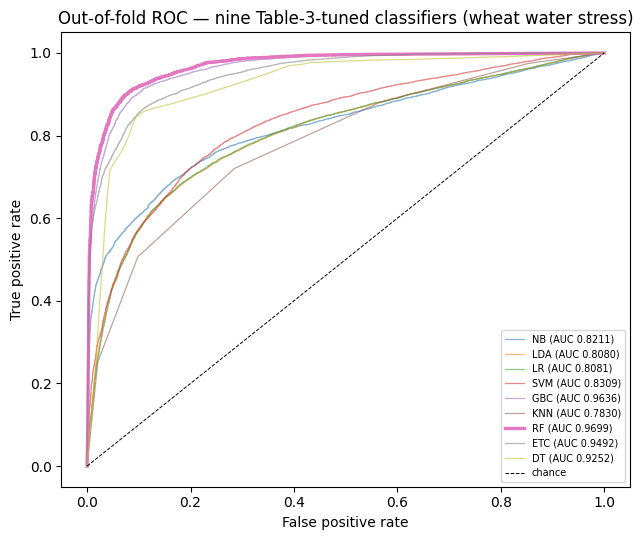

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6.5, 5.5))
oof = {}
for name, model in models.items():
    proba = numpy.zeros_like(y01, dtype=float)
    for fit_idx, test_idx in skf.split(X, y01):
        model.fit(X[fit_idx], y01[fit_idx])
        proba[test_idx] = model.predict_proba(X[test_idx])[:, 1]
    oof[name] = proba
for name, proba in oof.items():
    fpr, tpr, _ = roc_curve(y01, proba)
    lw, alpha = (2.4, 1.0) if name == "RF" else (0.9, 0.55)
    ax.plot(fpr, tpr, lw=lw, alpha=alpha, label=f"{name} (AUC {roc_auc_score(y01, proba):.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.7, label="chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Out-of-fold ROC — nine Table-3-tuned classifiers (wheat water stress)")
ax.legend(fontsize=7, loc="lower right"); fig.tight_layout(); plt.show()
fig.savefig("/content/roc_reproduction.png", dpi=150)

## 8. Secondary demo: the paper's chosen pre-processing (pipeline II) on one deposited image / 参考デモ: パイプラインIIの前処理

The paper selects **TV-L1 (Primal-Dual) denoising + min-max contrast stretching** as the pre-processing that feeds segmentation/features (pipeline II in Fig. 1). To make the input side tangible, one raw chlorophyll-fluorescence canopy image from deposit `10.17632/jnjd835ncg` is downloaded and run through `cv2.denoise_TVL1` + min-max stretch. This is an illustration of the transform on a single image — **not** the authors' full 2,880-image pipeline and not a re-derivation of the deposited features.

**参考として、生CF画像1枚に TV-L1 デノイジング＋ミニマックス伸張を適用します。** 論文の全画像パイプラインの再実行ではありません。

In [ ]:
IMG_URL = "https://data.mendeley.com/public-files/datasets/jnjd835ncg/files/9ce2850f-cb01-4e2c-a454-48a46dad46a6/file_downloaded"
IMG_SHA = "0f34948371c4155cfe5de11742dcb3620eab8e8e3f85183ca0a747d482c61eaf"
img_path = DATA_DIR / "jnjd835ncg_0_0_0.png"
if not img_path.exists():
    fetch_mendeley(IMG_URL, img_path)
blob = img_path.read_bytes()
assert hashlib.sha256(blob).hexdigest() == IMG_SHA and len(blob) == 684_906
print(f"OK raw CF image: {len(blob):,} bytes, sha256 verified (deposit 10.17632/jnjd835ncg.2)")

info_url = "https://data.mendeley.com/public-files/datasets/jnjd835ncg/files/aab27722-e86d-4bfa-84c7-ef8a018cf188/file_downloaded"
info_path = DATA_DIR / "info.txt"
if not info_path.exists():
    fetch_mendeley(info_url, info_path)
print("deposit info.txt:", info_path.read_text(errors="replace").strip())

OK raw CF image: 684,906 bytes, sha256 verified (deposit 10.17632/jnjd835ncg.2)


deposit info.txt: Camera label: Flouro_TV
MM pro pixel X: 0
MM pro pixel Y: 0


opencv: 4.14.0 | denoise_TVL1 available: True


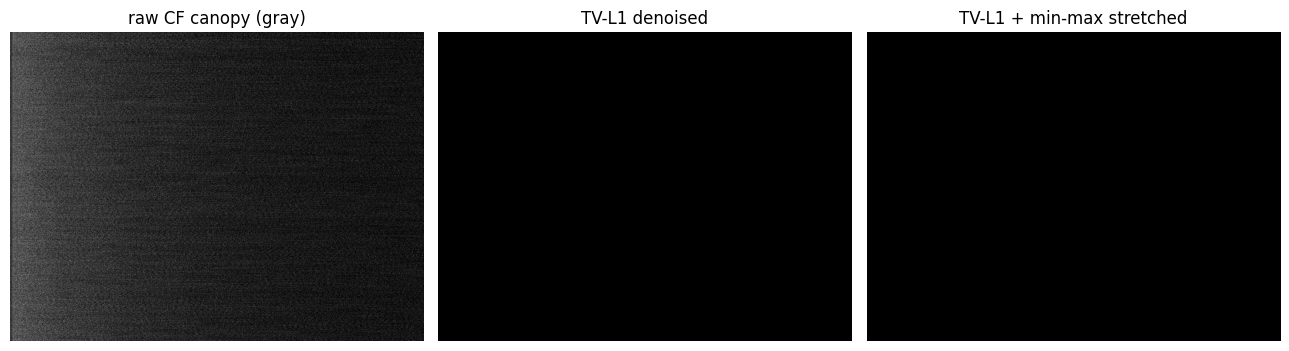

In [ ]:
import cv2
print("opencv:", cv2.__version__, "| denoise_TVL1 available:", hasattr(cv2, "denoise_TVL1"))
bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
assert bgr is not None, "cv2 could not parse the downloaded PNG"
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

denoised = numpy.zeros_like(gray)
cv2.denoise_TVL1(gray, denoised)                              # TV-L1 primal-dual denoising
stretched = cv2.normalize(denoised, None, 0, 255, cv2.NORM_MINMAX)  # min-max contrast stretching

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, im, title in zip(axes, [gray, denoised, stretched],
                         ["raw CF canopy (gray)", "TV-L1 denoised", "TV-L1 + min-max stretched"]):
    ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
fig.tight_layout(); plt.show()

## 9. Interpretation, differences from the paper, validation record / 解釈と差分、検証記録

**What this notebook establishes:** with the authors' deposited feature matrix and the Table 3 hyperparameters, the Random Forest reproduces the paper's headline global diagnostic accuracy (test AUC ≈ 0.91) under 10-fold cross-validation, and the model ranking (tree family on top) is visible in the outputs above. Exact AUC digits depend on the unpublished fold seed and augmentation details; deltas are printed in section 6.

**Known differences / limitations:**
- Features are **used as deposited** (unnamed 32 columns); feature re-derivation from images (PSII, GLCM windows, colour-band proportions) is out of scope, as is Cfit k-means segmentation.
- The deposit contains 17,328 rows while the paper text says the dataset was increased "10 times" its 2,880 images; the deposited matrix is treated as authoritative (its v2 record description says 2880×6). Observed row count is printed in section 3.
- Table 3 name-to-sklearn mappings are documented in section 4; the published SVM/GBC Table 2 rows are identical, likely a paper copy error.
- The pre-processing demo (section 8) applies the transform to one image only.
- A single-example CV reproduction does not verify dataset-level claims beyond Table 2/3.

**検証記録:** このノートブックは2026-10-02に新しいColab CPUランタイムで先頭から全セル実行され、出力付きで保存・公開されています（実測値は各セルの出力を参照）。

**References / 参考文献**
- Gupta, A., Kaur, H. & Kaur, T. (2023). PeerJ Computer Science 9:e1268. https://doi.org/10.7717/peerj-cs.1268
- Dataset: Gupta, Ankita (2022) "Automatic Water Stress detection in wheat crop canopy using Chlorophyll fluorescence image dataset", Mendeley Data, V2–V4. https://doi.org/10.17632/2mpd7d3vry
- Raw images: Sandhu, R. (2019) "Plant Stress Analysis Based on Chlorophyll Fluorescence and Image Processing", Mendeley Data, V2. https://doi.org/10.17632/jnjd835ncg
- Pre-processing deposit: https://doi.org/10.17632/4y8s925fkm ; segmentation deposit: https://doi.org/10.17632/crb5tkbvpb (both CC BY 4.0)

**Acknowledgement:** Notebook prepared by an AI-assisted reproduction pipeline (PhenoPaper/Colab); author code from the deposits was used only as inspection evidence, and all numerical results here were produced by this notebook's own cells.